<a href="https://www.kaggle.com/code/omborse771924/laptop-specifications-and-price-prediction-eda?scriptVersionId=325033257" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadmusharraf444/laptop-specifications-and-price-prediction-dataset/laptop_data (1).csv


## Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/muhammadmusharraf444/laptop-specifications-and-price-prediction-dataset/laptop_data (1).csv')

In [3]:
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [4]:
df.tail()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.64
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.72
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [5]:
df.describe()

,Unnamed: 0,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [6]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1298    False
1299    False
1300    False
1301    False
1302    False
Length: 1303, dtype: bool

In [8]:
df.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

## EDA

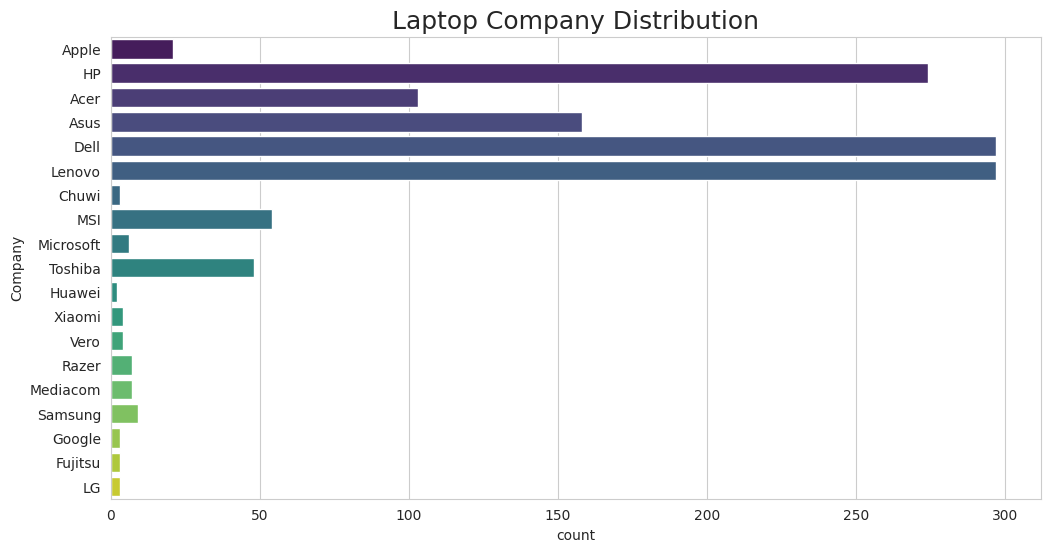

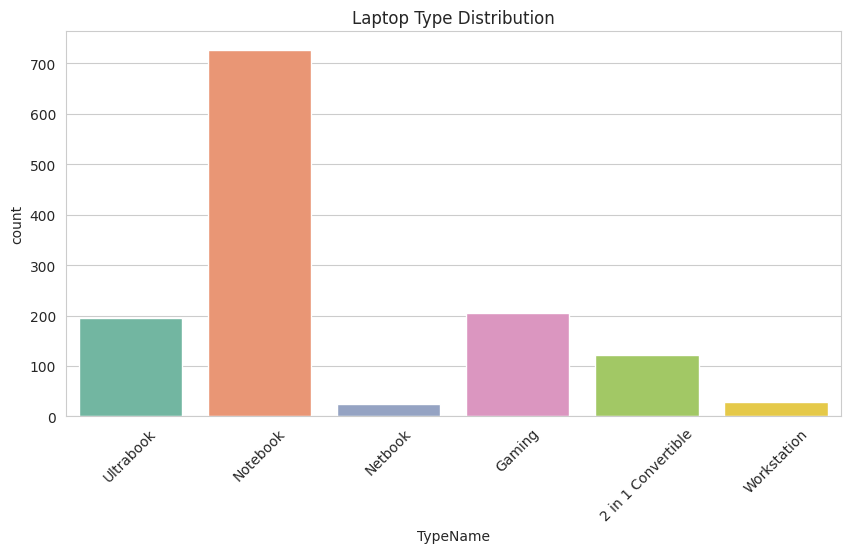

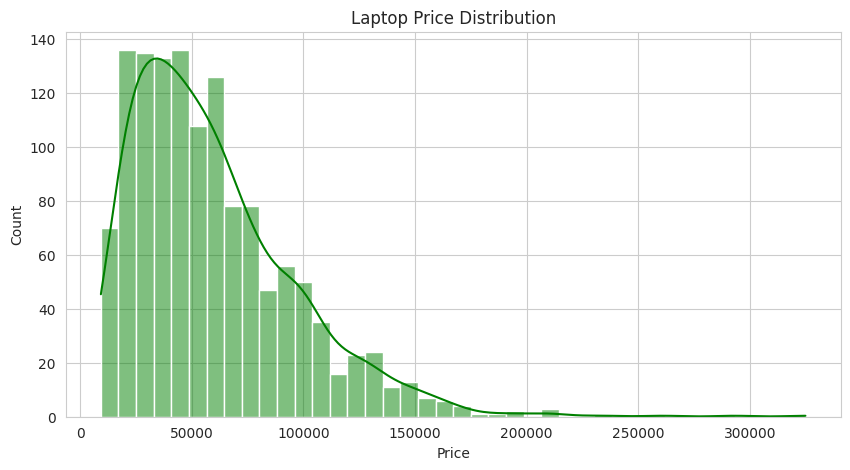

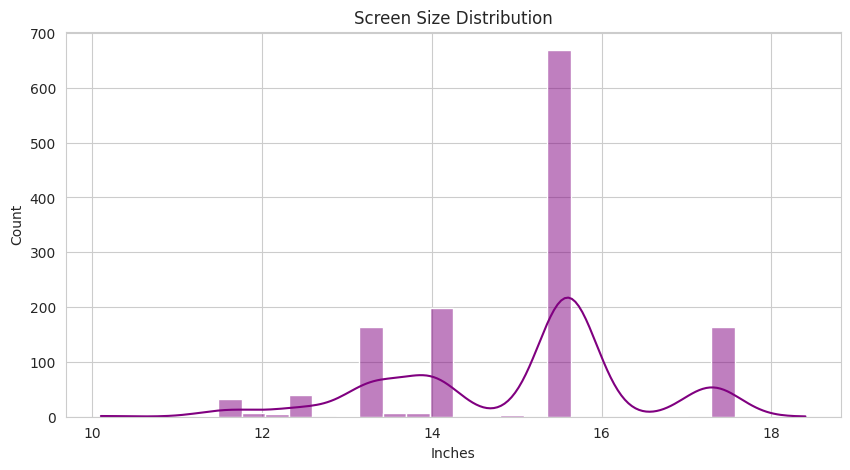

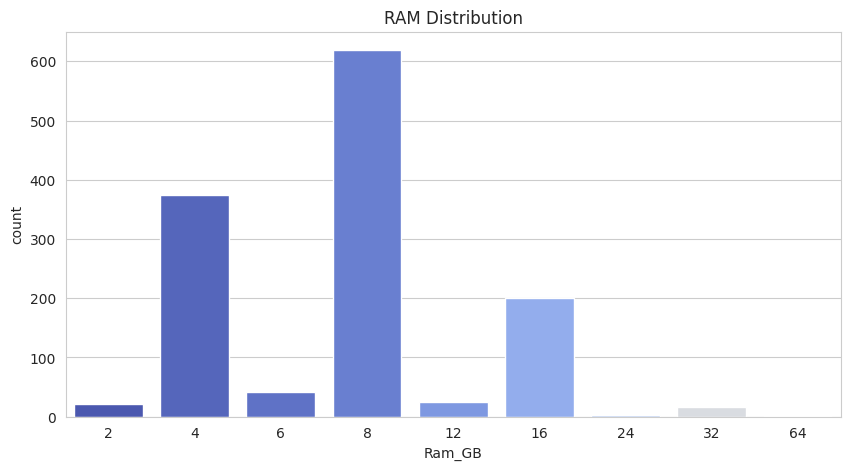

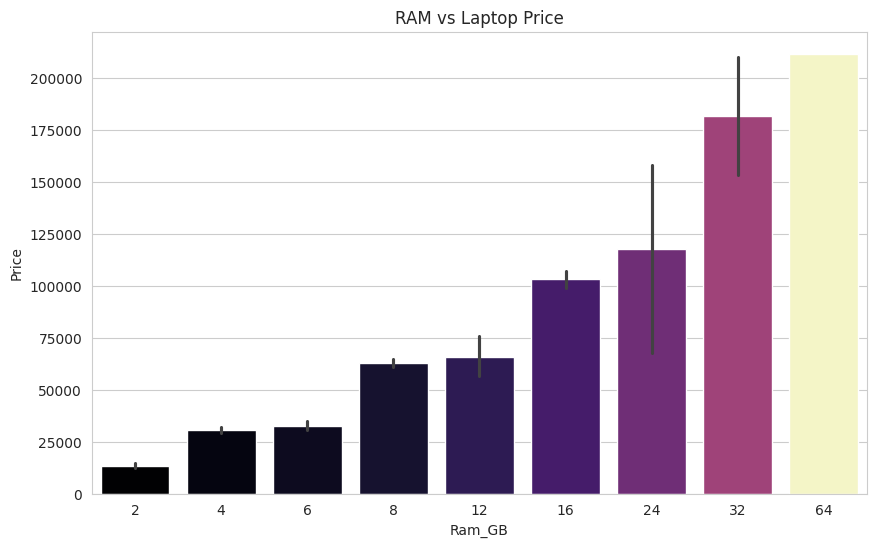

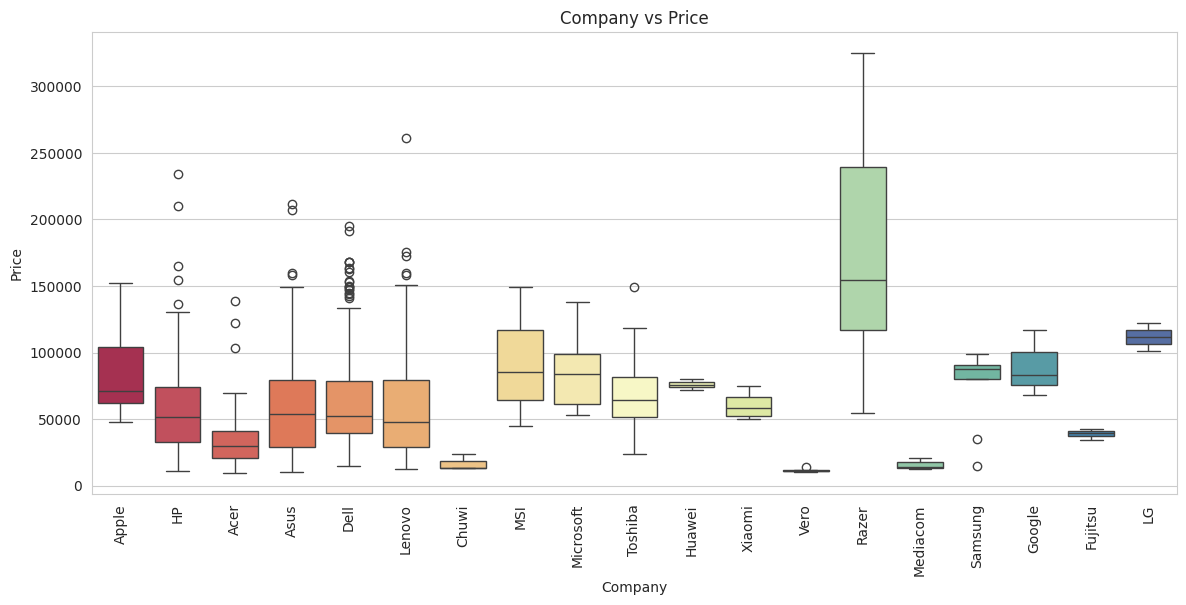

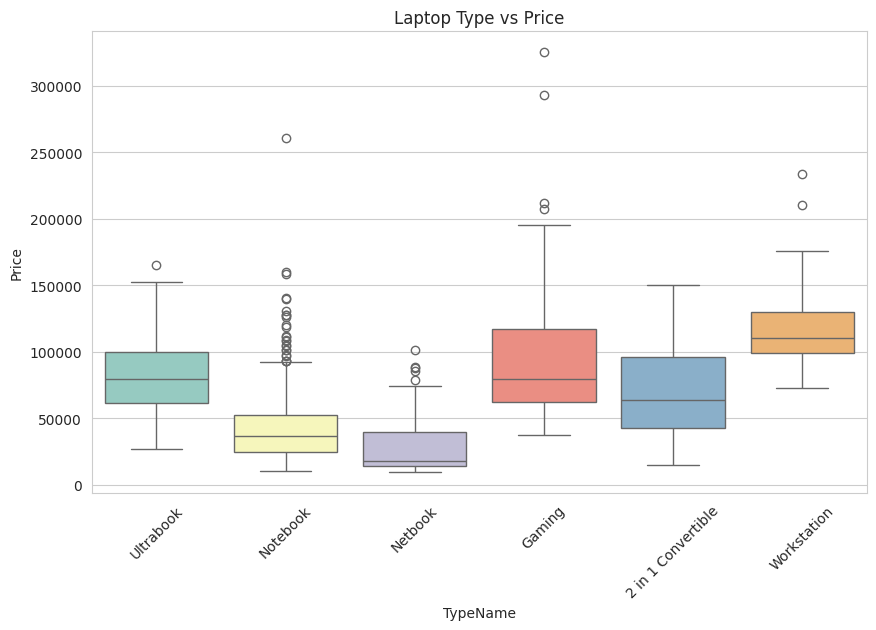

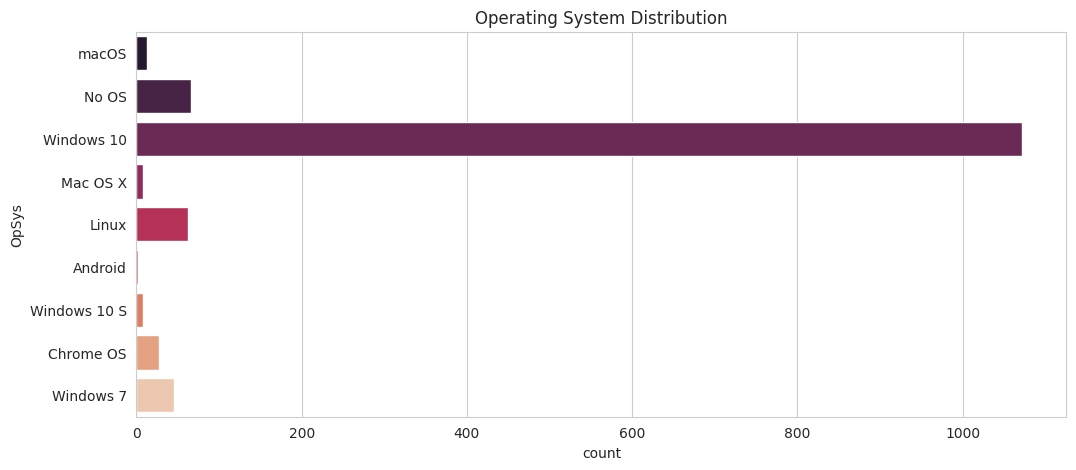

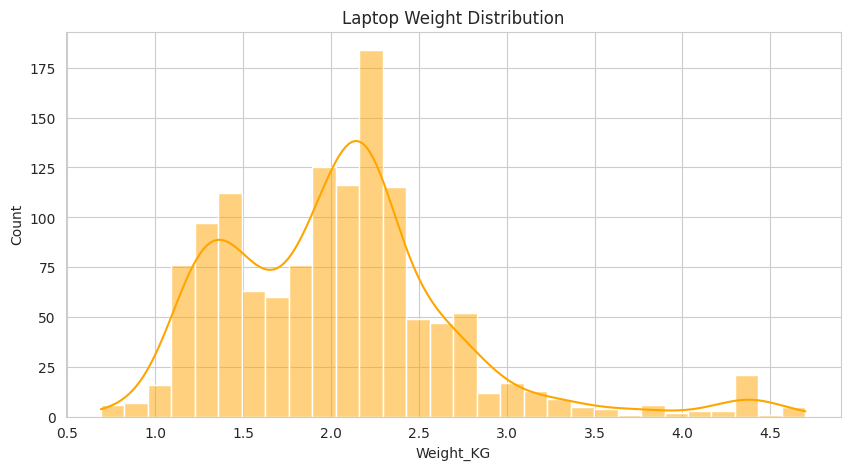

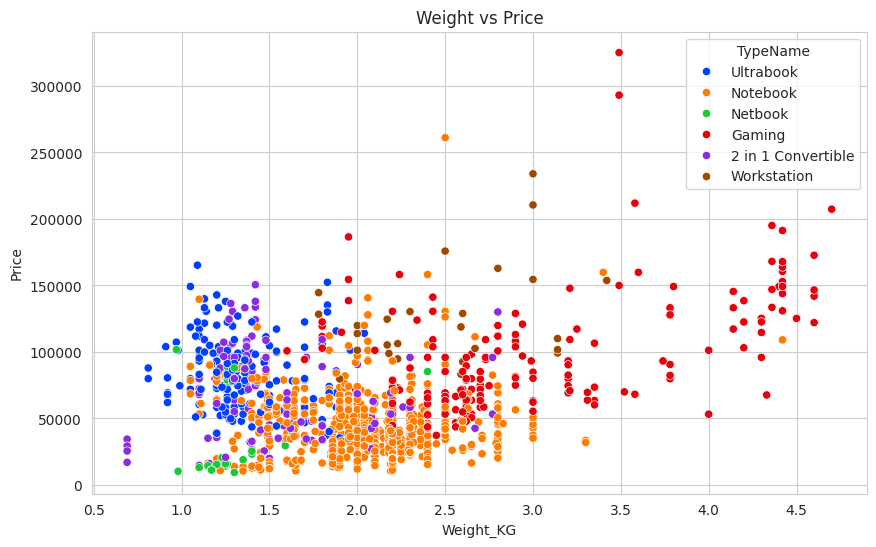

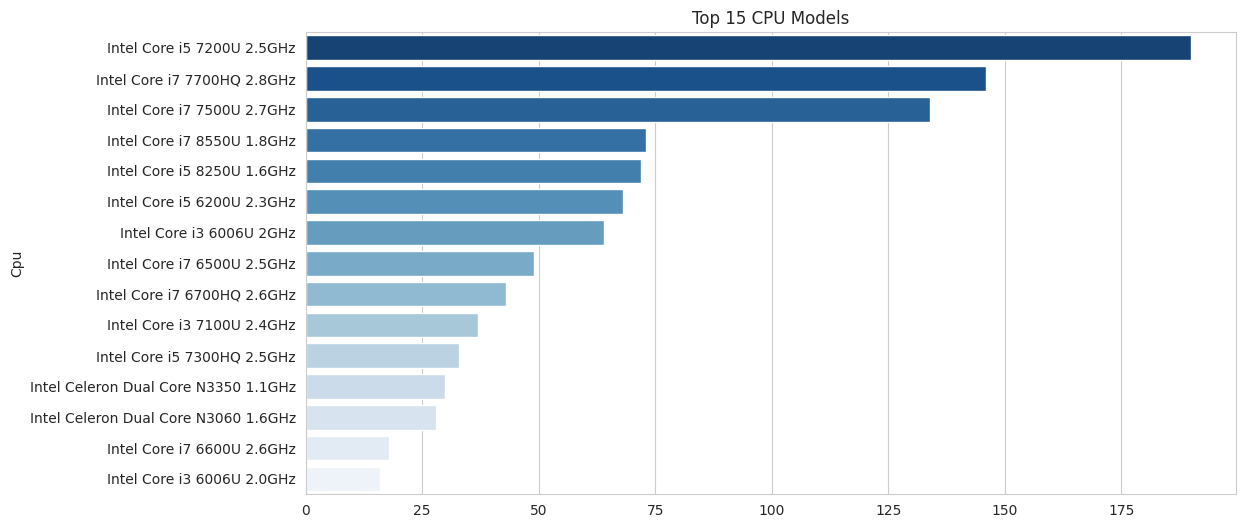

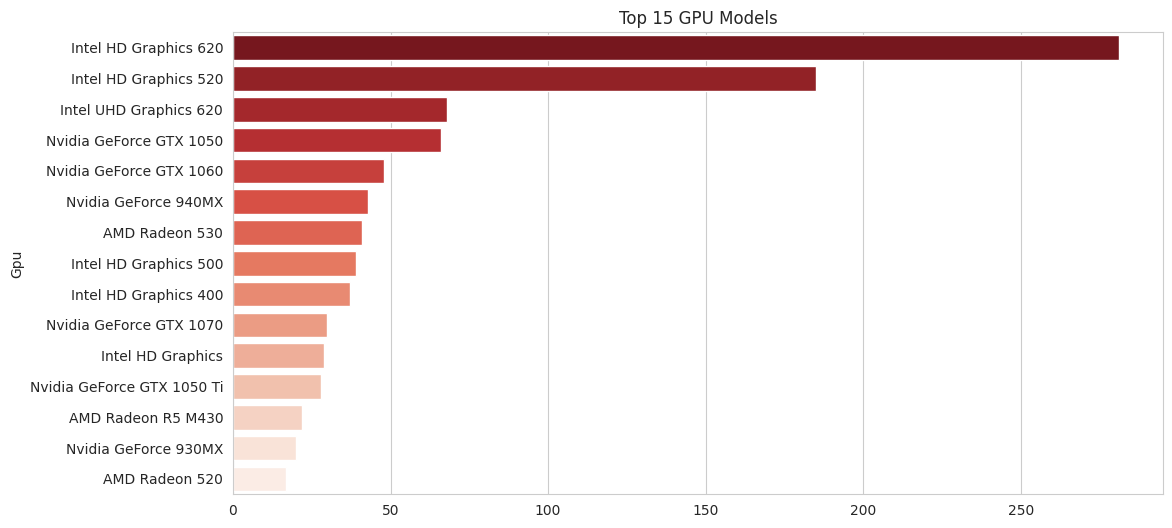

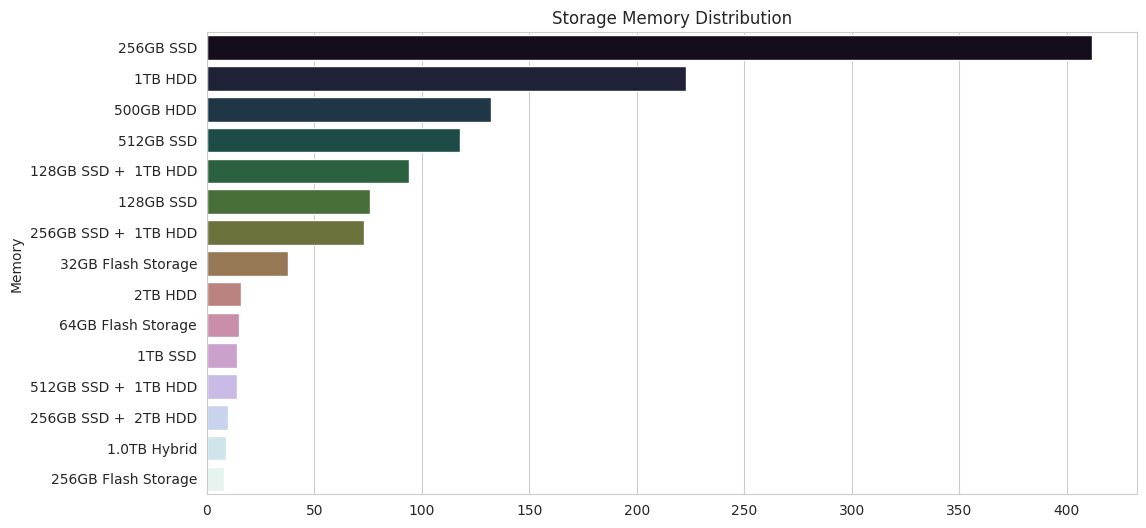

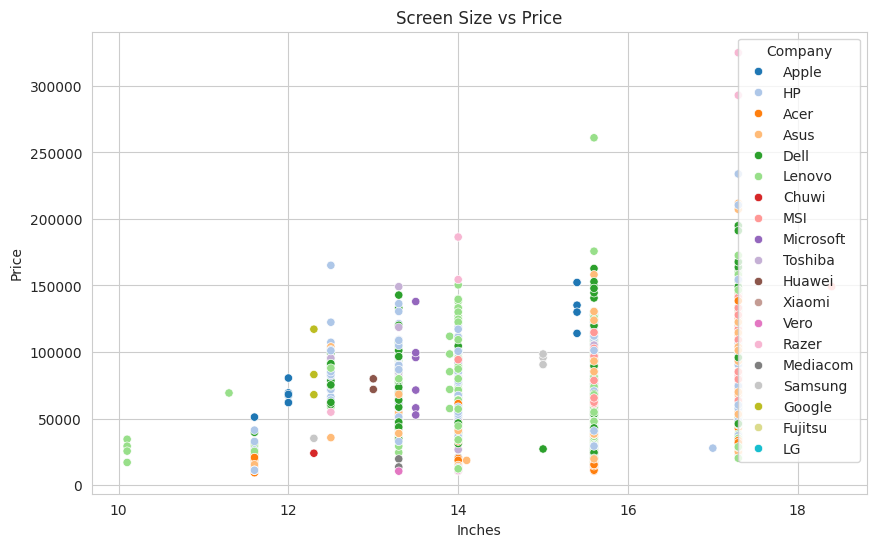

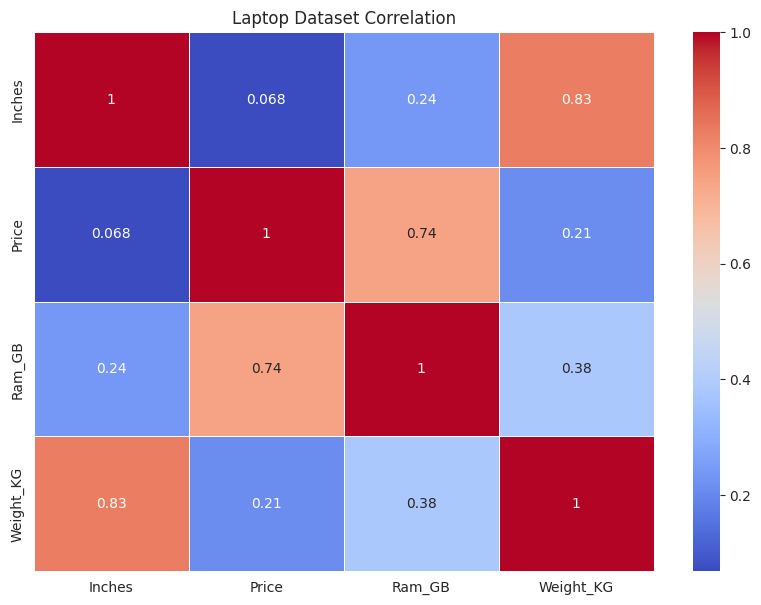

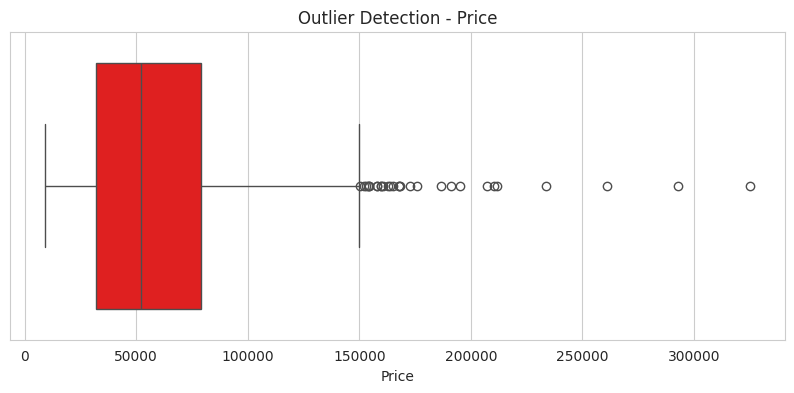

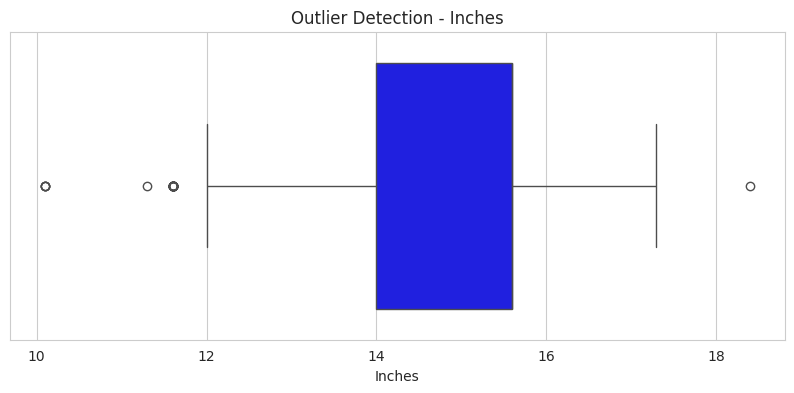

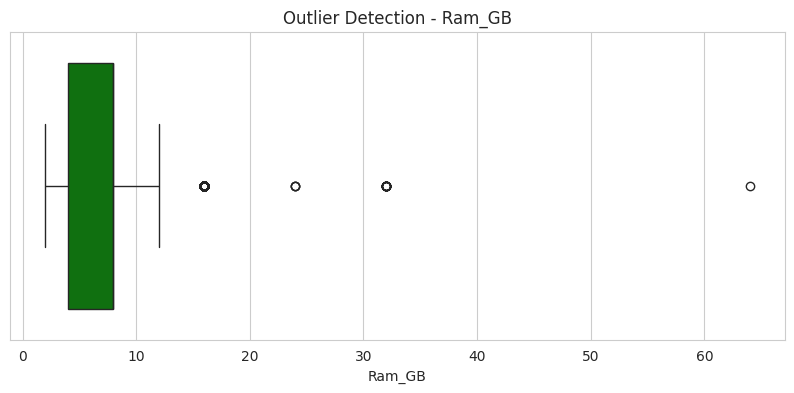

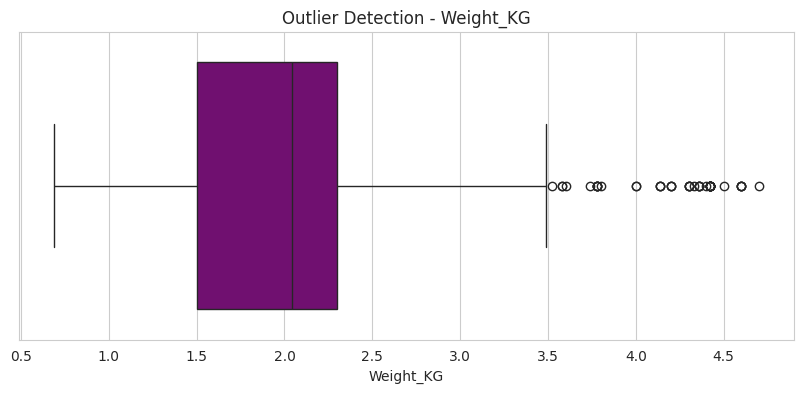

Laptop Visualization Completed Successfully!


In [9]:
# ============================================================
# LAPTOP PRICE DATASET - DETAILED VISUALIZATION
# UPDATED SEABORN VERSION
# ============================================================


# ============================================================
# IMPORT LIBRARIES
# ============================================================


import matplotlib.pyplot as plt
import seaborn as sns



sns.set_style("whitegrid")






# ============================================================
# DROP UNNECESSARY COLUMN
# ============================================================

if "Unnamed: 0" in df.columns:
    
    df.drop(
        "Unnamed: 0",
        axis=1,
        inplace=True
    )




# ============================================================
# SAFE RAM CLEANING
# ============================================================

if df["Ram"].dtype == "object":

    df["Ram_GB"] = (
        df["Ram"]
        .str.replace("GB", "", regex=False)
        .astype(int)
    )

else:

    df["Ram_GB"] = df["Ram"]



# ============================================================
# SAFE WEIGHT CLEANING
# ============================================================

if df["Weight"].dtype == "object":

    df["Weight_KG"] = (
        df["Weight"]
        .str.replace("kg", "", regex=False)
        .astype(float)
    )

else:

    df["Weight_KG"] = df["Weight"]



# ============================================================
# 1. COMPANY DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))


sns.countplot(

    data=df,

    y="Company",

    hue="Company",

    palette="viridis",

    legend=False

)


plt.title(
    "Laptop Company Distribution",
    fontsize=18
)


plt.show()








# ============================================================
# 2. LAPTOP TYPE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))


sns.countplot(

    data=df,

    x="TypeName",

    hue="TypeName",

    palette="Set2",

    legend=False

)


plt.xticks(rotation=45)


plt.title(
    "Laptop Type Distribution"
)


plt.show()









# ============================================================
# 3. PRICE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Price"],

    bins=40,

    kde=True,

    color="green"

)


plt.title(
    "Laptop Price Distribution"
)


plt.show()







# ============================================================
# 4. SCREEN SIZE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Inches"],

    bins=30,

    kde=True,

    color="purple"

)



plt.title(
    "Screen Size Distribution"
)


plt.show()







# ============================================================
# 5. RAM DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,5))


sns.countplot(

    data=df,

    x="Ram_GB",

    hue="Ram_GB",

    palette="coolwarm",

    legend=False

)


plt.title(
    "RAM Distribution"
)


plt.show()







# ============================================================
# 6. RAM VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.barplot(

    data=df,

    x="Ram_GB",

    y="Price",

    hue="Ram_GB",

    palette="magma",

    legend=False

)


plt.title(
    "RAM vs Laptop Price"
)


plt.show()







# ============================================================
# 7. COMPANY VS PRICE
# ============================================================

plt.figure(figsize=(14,6))


sns.boxplot(

    data=df,

    x="Company",

    y="Price",

    hue="Company",

    palette="Spectral",

    legend=False

)


plt.xticks(rotation=90)


plt.title(
    "Company vs Price"
)


plt.show()









# ============================================================
# 8. TYPE VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

    data=df,

    x="TypeName",

    y="Price",

    hue="TypeName",

    palette="Set3",

    legend=False

)


plt.xticks(rotation=45)


plt.title(
    "Laptop Type vs Price"
)


plt.show()









# ============================================================
# 9. OPERATING SYSTEM COUNT
# ============================================================

plt.figure(figsize=(12,5))


sns.countplot(

    data=df,

    y="OpSys",

    hue="OpSys",

    palette="rocket",

    legend=False

)


plt.title(
    "Operating System Distribution"
)


plt.show()








# ============================================================
# 10. WEIGHT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Weight_KG"],

    kde=True,

    bins=30,

    color="orange"

)


plt.title(
    "Laptop Weight Distribution"
)


plt.show()









# ============================================================
# 11. WEIGHT VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    data=df,

    x="Weight_KG",

    y="Price",

    hue="TypeName",

    palette="bright"

)


plt.title(
    "Weight vs Price"
)


plt.show()


# ============================================================
# CPU ANALYSIS (SAFE)
# ============================================================

if "Cpu" in df.columns:

    cpu = df["Cpu"].value_counts().head(15)


    plt.figure(figsize=(12,6))


    sns.barplot(

        x=cpu.values,

        y=cpu.index,

        hue=cpu.index,

        palette="Blues_r",

        legend=False

    )


    plt.title(
        "Top 15 CPU Models"
    )


    plt.show()


else:

    print("Cpu column not available (already processed or removed)")





# ============================================================
# GPU ANALYSIS (SAFE)
# ============================================================

if "Gpu" in df.columns:


    gpu = df["Gpu"].value_counts().head(15)


    plt.figure(figsize=(12,6))


    sns.barplot(

        x=gpu.values,

        y=gpu.index,

        hue=gpu.index,

        palette="Reds_r",

        legend=False

    )


    plt.title(
        "Top 15 GPU Models"
    )


    plt.show()


else:

    print("Gpu column not available (already processed or removed)")

















# ============================================================
# 14. MEMORY DISTRIBUTION
# ============================================================


memory=df["Memory"].value_counts().head(15)


plt.figure(figsize=(12,6))


sns.barplot(

    x=memory.values,

    y=memory.index,

    hue=memory.index,

    palette="cubehelix",

    legend=False

)


plt.title(
    "Storage Memory Distribution"
)


plt.show()









# ============================================================
# 15. SCREEN SIZE VS PRICE
# ============================================================


plt.figure(figsize=(10,6))


sns.scatterplot(

    data=df,

    x="Inches",

    y="Price",

    hue="Company",

    palette="tab20"

)


plt.title(
    "Screen Size vs Price"
)


plt.show()







# ============================================================
# 16. CORRELATION HEATMAP
# ============================================================


numeric_df=df.select_dtypes(
    include=np.number
)


plt.figure(figsize=(10,7))


sns.heatmap(

    numeric_df.corr(),

    annot=True,

    cmap="coolwarm",

    linewidth=0.5

)


plt.title(
    "Laptop Dataset Correlation"
)


plt.show()








# ============================================================
# 17. OUTLIER DETECTION
# ============================================================


features=[

    "Price",

    "Inches",

    "Ram_GB",

    "Weight_KG"

]


colors=[

    "red",

    "blue",

    "green",

    "purple"

]


for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )


    plt.title(

        f"Outlier Detection - {feature}"

    )


    plt.show()








# ============================================================
# FINISH
# ============================================================


print(
    "Laptop Visualization Completed Successfully!"
)

## Features Engineering


Logistic Regression
Accuracy: 0.8046
              precision    recall  f1-score   support

        High       0.78      0.85      0.81        87
         Low       0.88      0.92      0.90        87
      Medium       0.75      0.64      0.69        87

    accuracy                           0.80       261
   macro avg       0.80      0.80      0.80       261
weighted avg       0.80      0.80      0.80       261


Decision Tree
Accuracy: 0.7893
              precision    recall  f1-score   support

        High       0.80      0.83      0.81        87
         Low       0.89      0.84      0.86        87
      Medium       0.69      0.70      0.69        87

    accuracy                           0.79       261
   macro avg       0.79      0.79      0.79       261
weighted avg       0.79      0.79      0.79       261


Random Forest
Accuracy: 0.8391
              precision    recall  f1-score   support

        High       0.85      0.86      0.86        87
         Low       0.87    

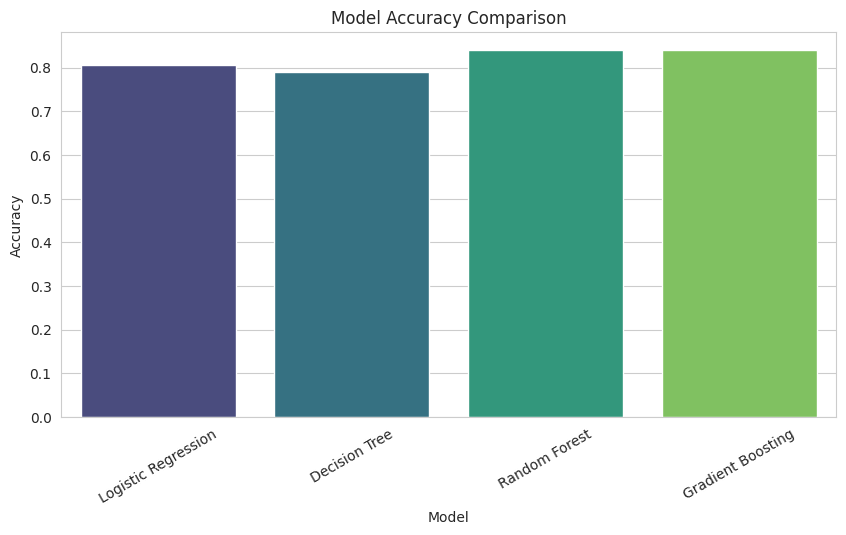

BEST MODEL: Random Forest


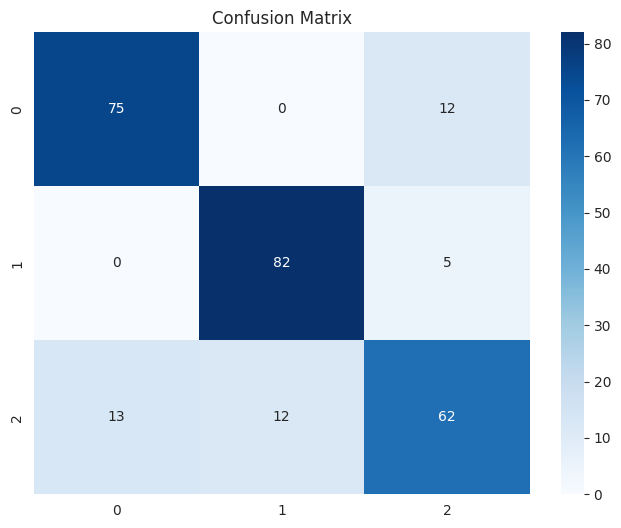

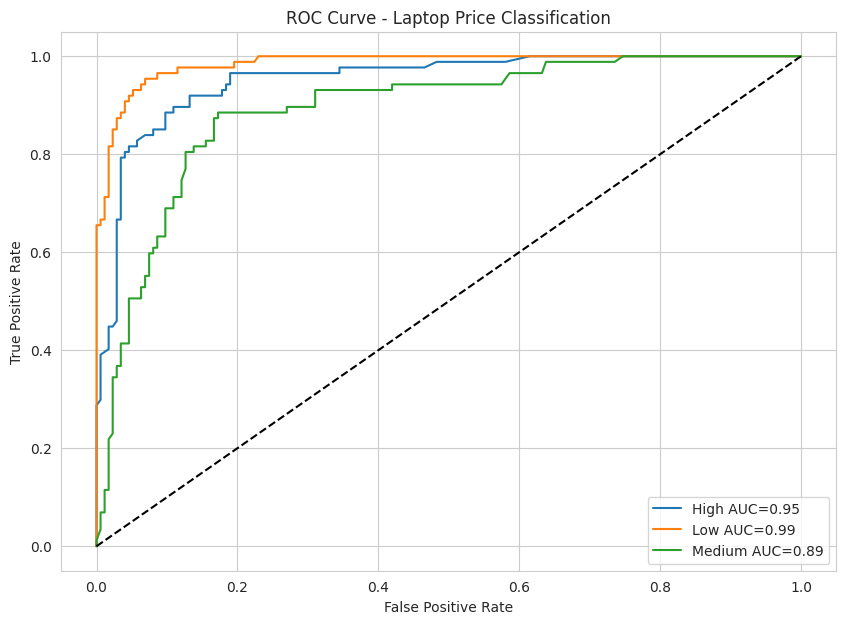


FINAL RESULTS
Logistic Regression : 0.8046
Decision Tree : 0.7893
Random Forest : 0.8391
Gradient Boosting : 0.8391
Best Model: Random Forest
Best Accuracy: 0.8391


In [10]:



from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)







# ============================================================
# REMOVE EXTRA COLUMN
# ============================================================

if "Unnamed: 0" in df.columns:

    df.drop(
        "Unnamed: 0",
        axis=1,
        inplace=True
    )




# ============================================================
# FEATURE ENGINEERING
# ============================================================


# RAM

if df["Ram"].dtype=="object":

    df["Ram"] = (
        df["Ram"]
        .str.replace("GB","")
        .astype(int)
    )



# Weight

if df["Weight"].dtype=="object":

    df["Weight"] = (
        df["Weight"]
        .str.replace("kg","")
        .astype(float)
    )





# CPU BRAND

if "Cpu" in df.columns:

    df["Cpu_Brand"] = (
        df["Cpu"]
        .apply(
            lambda x:x.split()[0]
        )
    )

    df.drop(
        "Cpu",
        axis=1,
        inplace=True
    )




# GPU BRAND

if "Gpu" in df.columns:

    df["Gpu_Brand"] = (
        df["Gpu"]
        .apply(
            lambda x:x.split()[0]
        )
    )


    df.drop(
        "Gpu",
        axis=1,
        inplace=True
    )





# ============================================================
# CREATE TARGET
# ============================================================
# Convert price regression into classification


df["Price_Category"] = pd.qcut(

    df["Price"],

    q=3,

    labels=[
        "Low",
        "Medium",
        "High"
    ]

)



# Remove original price to avoid leakage

df.drop(
    "Price",
    axis=1,
    inplace=True
)





# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop(
    "Price_Category",
    axis=1
)


y = df[
    "Price_Category"
]





# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)






# ============================================================
# NUMERIC AND CATEGORY COLUMNS
# ============================================================

numeric_cols = X.select_dtypes(
    include=np.number
).columns



categorical_cols = X.select_dtypes(
    include="object"
).columns





# ============================================================
# PREPROCESSING PIPELINE
# ============================================================


numeric_pipe = Pipeline(

steps=[

(
"imputer",
SimpleImputer(
strategy="median"
)

),

(
"scaler",
StandardScaler()
)

]

)




category_pipe = Pipeline(

steps=[

(
"imputer",
SimpleImputer(
strategy="most_frequent"
)

),


(
"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)

]

)




preprocessor = ColumnTransformer(

transformers=[

(
"num",
numeric_pipe,
numeric_cols
),


(
"cat",
category_pipe,
categorical_cols
)

]

)






# ============================================================
# ML MODELS
# ============================================================


models={


"Logistic Regression":

LogisticRegression(
max_iter=1000
),



"Decision Tree":

DecisionTreeClassifier(
random_state=42
),




"Random Forest":

RandomForestClassifier(

n_estimators=300,

random_state=42

),




"Gradient Boosting":

GradientBoostingClassifier(
random_state=42
)

}





results={}

trained={}





# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():


    print("\n====================")
    print(name)
    print("====================")


    pipe=Pipeline(

    steps=[


    (
    "preprocess",
    preprocessor
    ),


    (
    "model",
    model
    )

    ]

    )


    pipe.fit(
        X_train,
        y_train
    )



    pred=pipe.predict(
        X_test
    )


    acc=accuracy_score(
        y_test,
        pred
    )


    results[name]=acc

    trained[name]=pipe



    print(
        "Accuracy:",
        round(acc,4)
    )


    print(
        classification_report(
            y_test,
            pred
        )
    )






# ============================================================
# ACCURACY GRAPH
# ============================================================


accuracy_df=pd.DataFrame({

"Model":results.keys(),

"Accuracy":results.values()

})



plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)


plt.title(
"Model Accuracy Comparison"
)


plt.xticks(rotation=30)


plt.show()








# ============================================================
# BEST MODEL
# ============================================================


best_name=max(
    results,
    key=results.get
)


best_model=trained[
    best_name
]


print(
    "BEST MODEL:",
    best_name
)





# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred=best_model.predict(
    X_test
)



plt.figure(figsize=(8,6))


sns.heatmap(

confusion_matrix(
y_test,
best_pred
),

annot=True,

fmt="d",

cmap="Blues"

)



plt.title(
"Confusion Matrix"
)


plt.show()









# ============================================================
# MULTICLASS ROC CURVE
# ============================================================


classes=np.unique(y)



y_bin=label_binarize(

y_test,

classes=classes

)



prob=best_model.predict_proba(
    X_test
)




plt.figure(figsize=(10,7))



for i in range(len(classes)):


    fpr,tpr,_=roc_curve(

    y_bin[:,i],

    prob[:,i]

    )



    auc=roc_auc_score(

    y_bin[:,i],

    prob[:,i]

    )



    plt.plot(

    fpr,

    tpr,

    label=f"{classes[i]} AUC={auc:.2f}"

    )




plt.plot(
[0,1],
[0,1],
"k--"
)



plt.xlabel(
"False Positive Rate"
)



plt.ylabel(
"True Positive Rate"
)



plt.title(
"ROC Curve - Laptop Price Classification"
)



plt.legend()


plt.show()





# ============================================================
# FINAL SUMMARY
# ============================================================

print("\nFINAL RESULTS")
print("====================")


for model,score in results.items():

    print(
        model,
        ":",
        round(score,4)
    )


print("====================")


print(
"Best Model:",
best_name
)


print(
"Best Accuracy:",
round(max(results.values()),4)
)

## Thank You........Please Upvote